In [35]:
import time
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
import torch

In [36]:
# Check if CUDA is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [37]:
# Define the models to compare
model_paths = [
    r"models/yolov10m.pt",
    r"models/yolo11m.pt",
    r"models/yolov8m.pt",
    r"models/yolov10n.pt",
    # r"models/yolov8m-worldv2.pt",
]

In [40]:
# Define a function to run inference and collect metrics
def run_inference(model_path, video_path):
    model = YOLO(model_path).to(device)
    cap = cv2.VideoCapture(video_path)
    assert cap.isOpened(), "Error reading video file"

    detected_objects = []

    start_time = time.time()  # Record the start time

    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break
        results = model(frame)
        detected_objects.append(len(results[0].boxes))

    end_time = time.time()  # Record the end time
    total_processing_time = end_time - start_time  # Calculate total processing time

    cap.release()
    return total_processing_time, np.mean(detected_objects)

In [ ]:
# Collect metrics for each model
metrics = {}
# video_path = r"videos/vehicle-counting-low.mp4" # 21 sec video
# video_path = r"videos/highway_two_lane.mp4" # 42 sec video
video_path = r"videos/highway_night.mp4" # 21 sec video, night scene
for model_path in model_paths:
    total_processing_time, avg_detected_objects = run_inference(model_path, video_path)
    metrics[model_path] = {
        "total_processing_time": total_processing_time,
        "avg_detected_objects": avg_detected_objects
    }

# Print collected metrics
print(metrics)


0: 384x640 16 cars, 30.0ms
Speed: 2.0ms preprocess, 30.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 16 cars, 28.0ms
Speed: 1.0ms preprocess, 28.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 17 cars, 27.0ms
Speed: 2.0ms preprocess, 27.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 cars, 28.0ms
Speed: 1.0ms preprocess, 28.0ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 15 cars, 23.0ms
Speed: 1.0ms preprocess, 23.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 14 cars, 23.0ms
Speed: 2.0ms preprocess, 23.0ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 16 cars, 23.0ms
Speed: 3.0ms preprocess, 23.0ms inference, 0.0ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 16 cars, 23.0ms
Speed: 1.0ms preprocess, 23.0ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)


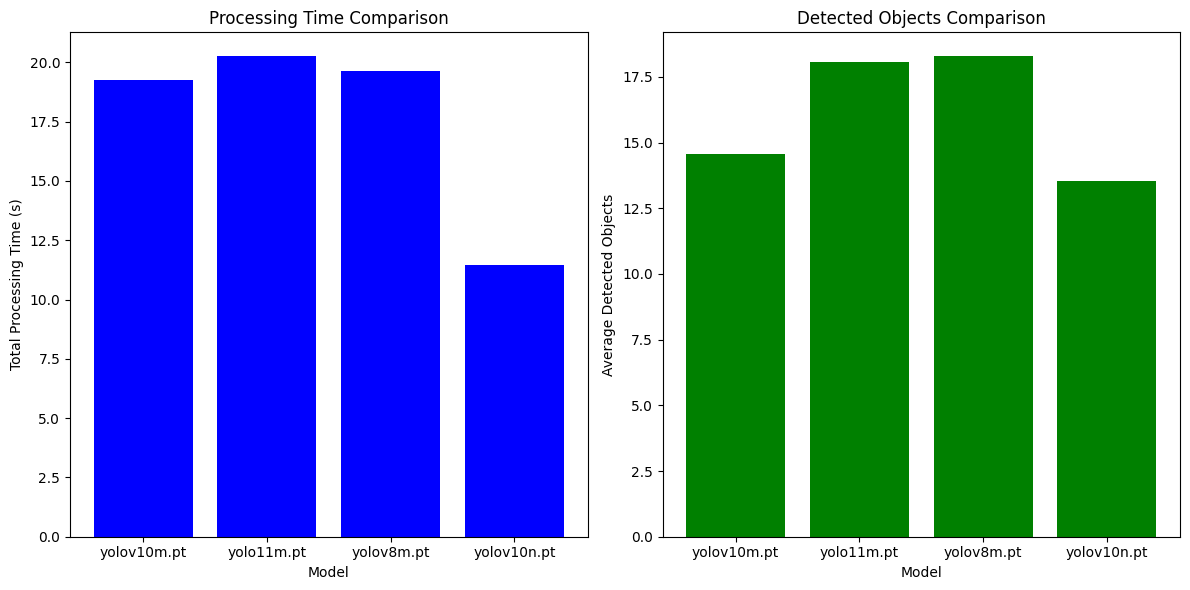

In [46]:
# Extract data for plotting
model_names = [path.split('/')[-1] for path in model_paths]
processing_times = [metrics[path]["total_processing_time"] for path in model_paths]
detected_objects = [metrics[path]["avg_detected_objects"] for path in model_paths]

# Create a bar chart for processing times
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.bar(model_names, processing_times, color='blue')
plt.xlabel('Model')
plt.ylabel('Total Processing Time (s)')
plt.title('Processing Time Comparison')

# Create a bar chart for detected objects
plt.subplot(1, 2, 2)
plt.bar(model_names, detected_objects, color='green')
plt.xlabel('Model')
plt.ylabel('Average Detected Objects')
plt.title('Detected Objects Comparison')

# Show the charts
plt.tight_layout()
plt.show()